In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

In [2]:
%%fenicsx

"""
FEniCSx Function and Expression Evaluation
Extracted from Colab notebook

Demonstrates:
- Interpolation on cell subsets
- Point evaluation with bounding box trees
- UFL expression compilation and evaluation
- Facet expression evaluation for boundary fluxes
"""

# Import required libraries
from mpi4py import MPI
import numpy as np
import dolfinx
import dolfinx.fem
import dolfinx.mesh
import dolfinx.geometry
import ufl
import matplotlib.pyplot as plt

print(f"DOLFINx version: {dolfinx.__version__}")

# Create 3D mesh
N = 2
mesh = dolfinx.mesh.create_box(
    MPI.COMM_WORLD,
    [np.array([0, 0, 0]), np.array([2, 1.3, 0.8])],
    [N, N, N],
    dolfinx.mesh.CellType.tetrahedron,
    ghost_mode=dolfinx.mesh.GhostMode.shared_facet,
)

print(f"Mesh created:")
print(f"  - Number of cells: {mesh.topology.index_map(mesh.topology.dim).size_local}")
print(f"  - Spatial dimension: {mesh.geometry.dim}")

# Create discontinuous function space
V = dolfinx.fem.functionspace(mesh, ("DG", 2))
u = dolfinx.fem.Function(V)

print(f"Function space: DG-2")
print(f"  - DOFs: {V.dofmap.index_map.size_global}")

# Locate cells in left and right halves
tdim = mesh.topology.dim

left_cells = dolfinx.mesh.locate_entities(
    mesh, tdim, lambda x: x[0] <= 1 + 1e-14
)

right_cells = dolfinx.mesh.locate_entities(
    mesh, tdim, lambda x: x[0] >= 1 - 1e-14
)

print(f"Cell classification:")
print(f"  - Left cells (x ≤ 1): {len(left_cells)}")
print(f"  - Right cells (x ≥ 1): {len(right_cells)}")

# Interpolate on subsets
u.interpolate(lambda x: x[0]**2, cells0=left_cells)
u.interpolate(lambda x: x[1], cells0=right_cells)

# CRITICAL: Scatter forward after subset interpolation
u.x.scatter_forward()

print("Piecewise function interpolated successfully")
print(f"  - min(u) = {np.min(u.x.array):.4f}")
print(f"  - max(u) = {np.max(u.x.array):.4f}")

# Step 1: Create bounding box tree for efficient search
bb_tree = dolfinx.geometry.bb_tree(mesh, mesh.topology.dim, padding=1e-10)

print("Bounding box tree created")
print("  - Enables O(log n) point location")

# Define points to evaluate
points = np.array([
    [0.51, 0.32, 0],     # In left region (x < 1)
    [1.3, 0.834, 0]      # In right region (x > 1)
], dtype=mesh.geometry.x.dtype)

print(f"Points to evaluate:")
for i, pt in enumerate(points):
    print(f"  Point {i}: {pt}")

# Step 2a: Bounding box collision (fast, approximate)
potential_colliding_cells = dolfinx.geometry.compute_collisions_points(
    bb_tree, points
)

print("\nBounding box collisions:")
for i in range(len(points)):
    cells = potential_colliding_cells.links(i)
    print(f"  Point {i}: {len(cells)} potential cells")

# Step 2b: GJK algorithm collision (accurate)
colliding_cells = dolfinx.geometry.compute_colliding_cells(
    mesh, potential_colliding_cells, points
)

print("\nExact collisions (GJK algorithm):")
for i in range(len(points)):
    cells = colliding_cells.links(i)
    print(f"  Point {i}: {len(cells)} actual cells")

# Step 3: Prepare for evaluation (filter points on this process)
points_on_proc = []
cells = []
point_indices = []

for i, point in enumerate(points):
    if len(colliding_cells.links(i)) > 0:
        points_on_proc.append(point)
        cells.append(colliding_cells.links(i)[0])
        point_indices.append(i)

points_on_proc = np.array(points_on_proc, dtype=np.float64).reshape(-1, 3)
cells = np.array(cells, dtype=np.int32)

print(f"\nPoints found on this process: {len(points_on_proc)}")

# Evaluate function at points
u_values = u.eval(points_on_proc, cells)

print("\nFunction evaluation:")
for i, (pt, val) in enumerate(zip(points_on_proc, u_values)):
    original_idx = point_indices[i]
    print(f"  Point {original_idx} at {pt[:2]}: u = {val[0]:.4f}")

    # Verify with analytical solution
    if pt[0] < 1:
        expected = pt[0]**2
        print(f"    Expected (x²): {expected:.4f}")
    else:
        expected = pt[1]
        print(f"    Expected (y): {expected:.4f}")

# Define line: y=0.3, z=0.2
x_vals = np.linspace(0, 2, 50)
y_vals = np.full_like(x_vals, 0.3)
z_vals = np.full_like(x_vals, 0.2)
line_points = np.vstack([x_vals, y_vals, z_vals]).T

# Find collisions
potential = dolfinx.geometry.compute_collisions_points(bb_tree, line_points)
colliding = dolfinx.geometry.compute_colliding_cells(mesh, potential, line_points)

# Extract points and cells on this process
points_on_proc = []
cells = []
for i, point in enumerate(line_points):
    if len(colliding.links(i)) > 0:
        points_on_proc.append(point)
        cells.append(colliding.links(i)[0])

if len(points_on_proc) > 0:
    points_on_proc = np.array(points_on_proc).reshape(-1, 3)
    cells = np.array(cells, dtype=np.int32)
    u_line = u.eval(points_on_proc, cells)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(points_on_proc[:, 0], u_line.flatten(), 'ro-', label='u(x, 0.3, 0.2)')
    plt.axvline(x=1, color='k', linestyle='--', label='x=1 (discontinuity)')
    plt.xlabel('x')
    plt.ylabel('u')
    plt.title('Piecewise Function Along Line')
    plt.grid(True)
    plt.legend()
    plt.savefig("u_along_line.png", dpi=300, bbox_inches="tight")

    plt.close()

    print(f"Evaluated at {len(points_on_proc)} points along line")
else:
    print("No points found on this process")

# Create vector function space
mesh_vec = dolfinx.mesh.create_unit_cube(
    MPI.COMM_WORLD, 5, 5, 5,
    dolfinx.mesh.CellType.hexahedron
)

V_vec = dolfinx.fem.functionspace(mesh_vec, ("Lagrange", 2, (3,)))
u_vec = dolfinx.fem.Function(V_vec)

print("Vector function space created")
print(f"  - Components: 3")
print(f"  - DOFs: {V_vec.dofmap.index_map.size_global * 3}")

# Define vector field
def f(x):
    return (x[2]**2, x[0] + x[1], x[1] * x[2])

u_vec.interpolate(lambda x: f(x))

print("Vector field interpolated:")
print("  u = (z², x+y, yz)")

# Define curl expression
curl_u = ufl.curl(u_vec)

print("\nCurl expression defined:")
print("  ∇×u = (∂u₂/∂y - ∂u₁/∂z, ∂u₀/∂z - ∂u₂/∂x, ∂u₁/∂x - ∂u₀/∂y)")

# Compile expression at reference point
ref_point = np.array([[0.2, 0.3, 0.5]], dtype=np.float64)
expr = dolfinx.fem.Expression(curl_u, ref_point)

print(f"\nExpression compiled at reference point: {ref_point[0]}")

# Evaluate at random cells
num_cells_local = mesh_vec.topology.index_map(mesh_vec.topology.dim).size_local
cells = np.random.randint(0, num_cells_local, 3, dtype=np.int32)

curl_values = expr.eval(mesh_vec, cells)

# Get physical coordinates
x_expr = dolfinx.fem.Expression(ufl.SpatialCoordinate(mesh_vec), ref_point)
coords = x_expr.eval(mesh_vec, cells)

print("\nCurl evaluation:")
for i, (coord, curl_val) in enumerate(zip(coords, curl_values)):
    print(f"  Cell {cells[i]} at {coord[0]}: curl = {curl_val[0]}")

# Create scalar H¹ function
Q = dolfinx.fem.functionspace(mesh_vec, ("Lagrange", 2))
q = dolfinx.fem.Function(Q)

def scalar_func(x):
    return x[0]**2 + 2*x[1]**2 + x[1]*x[2]

q.interpolate(scalar_func)

print("Scalar function q created (H¹)")
print("  q = x² + 2y² + yz")

# Compute gradient (UFL expression)
grad_q = ufl.grad(q)

print("\nGradient expression:")
print("  ∇q = (2x, 4y+z, y)")

# Create H(curl) space (Nedelec)
P = dolfinx.fem.functionspace(mesh_vec, ("N1curl", 2))
p = dolfinx.fem.Function(P)

print("Target function space created (H(curl))")
print(f"  - Element: Nedelec (first kind)")
print(f"  - Degree: 2")

# Interpolate gradient into H(curl)
grad_expr = dolfinx.fem.Expression(
    grad_q, P.element.interpolation_points
)
p.interpolate(grad_expr)

print("\nGradient interpolated into H(curl) space")

# Verify accuracy by computing L² error
x = ufl.SpatialCoordinate(mesh_vec)

def grad_analytical(x):
    return (2*x[0], 4*x[1] + x[2], x[1])

f_exact = ufl.as_vector(grad_analytical(x))

# L² error
L2_error_form = dolfinx.fem.form(
    ufl.inner(p - f_exact, p - f_exact) * ufl.dx
)
local_error = dolfinx.fem.assemble_scalar(L2_error_form)
global_error = np.sqrt(mesh_vec.comm.allreduce(local_error, op=MPI.SUM))

print(f"\nL² error: {global_error:.2e}")
print("(Should be close to machine precision for polynomial functions)")

# Define heat flux on boundary
n = ufl.FacetNormal(mesh_vec)
heat_flux = ufl.dot(ufl.grad(q), n)

print("Heat flux defined:")
print("  flux = ∇q · n")

# Find boundary facets (y = 1)
tdim = mesh_vec.topology.dim
boundary_facets = dolfinx.mesh.locate_entities_boundary(
    mesh_vec, tdim - 1,
    lambda x: np.isclose(x[1], 1)
)

print(f"\nBoundary facets found: {len(boundary_facets)}")

# Create connectivity to find local facet indices
mesh_vec.topology.create_connectivity(tdim - 1, tdim)
f_to_c = mesh_vec.topology.connectivity(tdim - 1, tdim)

mesh_vec.topology.create_connectivity(tdim, tdim - 1)
c_to_f = mesh_vec.topology.connectivity(tdim, tdim - 1)

print("Mesh connectivity created")

# Build (cell, local_facet) pairs
cell_facet_pairs = []

for facet in boundary_facets:
    # Get cell containing this facet
    cells = f_to_c.links(facet)
    if len(cells) != 1:
        continue  # Skip if not exterior

    cell = cells[0]

    # Find local facet index
    facets = c_to_f.links(cell)
    local_idx = np.flatnonzero(facets == facet)

    if len(local_idx) == 1:
        cell_facet_pairs.append((cell, local_idx[0]))

cell_facet_pairs = np.array(cell_facet_pairs, dtype=np.int32)

print(f"Integration entities created: {len(cell_facet_pairs)}")
print(f"  Format: (cell_index, local_facet_index)")

# Evaluate heat flux at facet midpoints
facet_midpoint = np.array([[0.5, 0.5]], dtype=np.float64)

# Create expressions
facet_x_expr = dolfinx.fem.Expression(
    ufl.SpatialCoordinate(mesh_vec), facet_midpoint
)
heat_flux_expr = dolfinx.fem.Expression(
    heat_flux, facet_midpoint
)

# Evaluate
coordinates = facet_x_expr.eval(mesh_vec, cell_facet_pairs)
flux_values = heat_flux_expr.eval(mesh_vec, cell_facet_pairs)

print("\nHeat flux evaluation on boundary (y=1):")
print("Sample results:")
for i in range(min(5, len(coordinates))):
    coord = coordinates[i, 0]
    flux = flux_values[i, 0]

    # Analytical flux at y=1: ∂q/∂y = 4y + z = 4(1) + z = 4 + z
    analytical = 4.0 + coord[2]

    print(f"  Position {coord}: flux={flux:.2f}, analytical={analytical:.2f}")

DOLFINx version: 0.10.0
Mesh created:
  - Number of cells: 48
  - Spatial dimension: 3
Function space: DG-2
  - DOFs: 480
Cell classification:
  - Left cells (x ≤ 1): 24
  - Right cells (x ≥ 1): 24
Piecewise function interpolated successfully
  - min(u) = -0.0000
  - max(u) = 1.3000
Bounding box tree created
  - Enables O(log n) point location
Points to evaluate:
  Point 0: [0.51 0.32 0.  ]
  Point 1: [1.3   0.834 0.   ]

Bounding box collisions:
  Point 0: 6 potential cells
  Point 1: 6 potential cells

Exact collisions (GJK algorithm):
  Point 0: 1 actual cells
  Point 1: 1 actual cells

Points found on this process: 2

Function evaluation:
  Point 0 at [0.51 0.32]: u = 0.2601
    Expected (x²): 0.2601
  Point 1 at [1.3   0.834]: u = 0.8340
    Expected (y): 0.8340
Evaluated at 50 points along line
Vector function space created
  - Components: 3
  - DOFs: 3993
Vector field interpolated:
  u = (z², x+y, yz)

Curl expression defined:
  ∇×u = (∂u₂/∂y - ∂u₁/∂z, ∂u₀/∂z - ∂u₂/∂x, ∂u₁/∂x - 

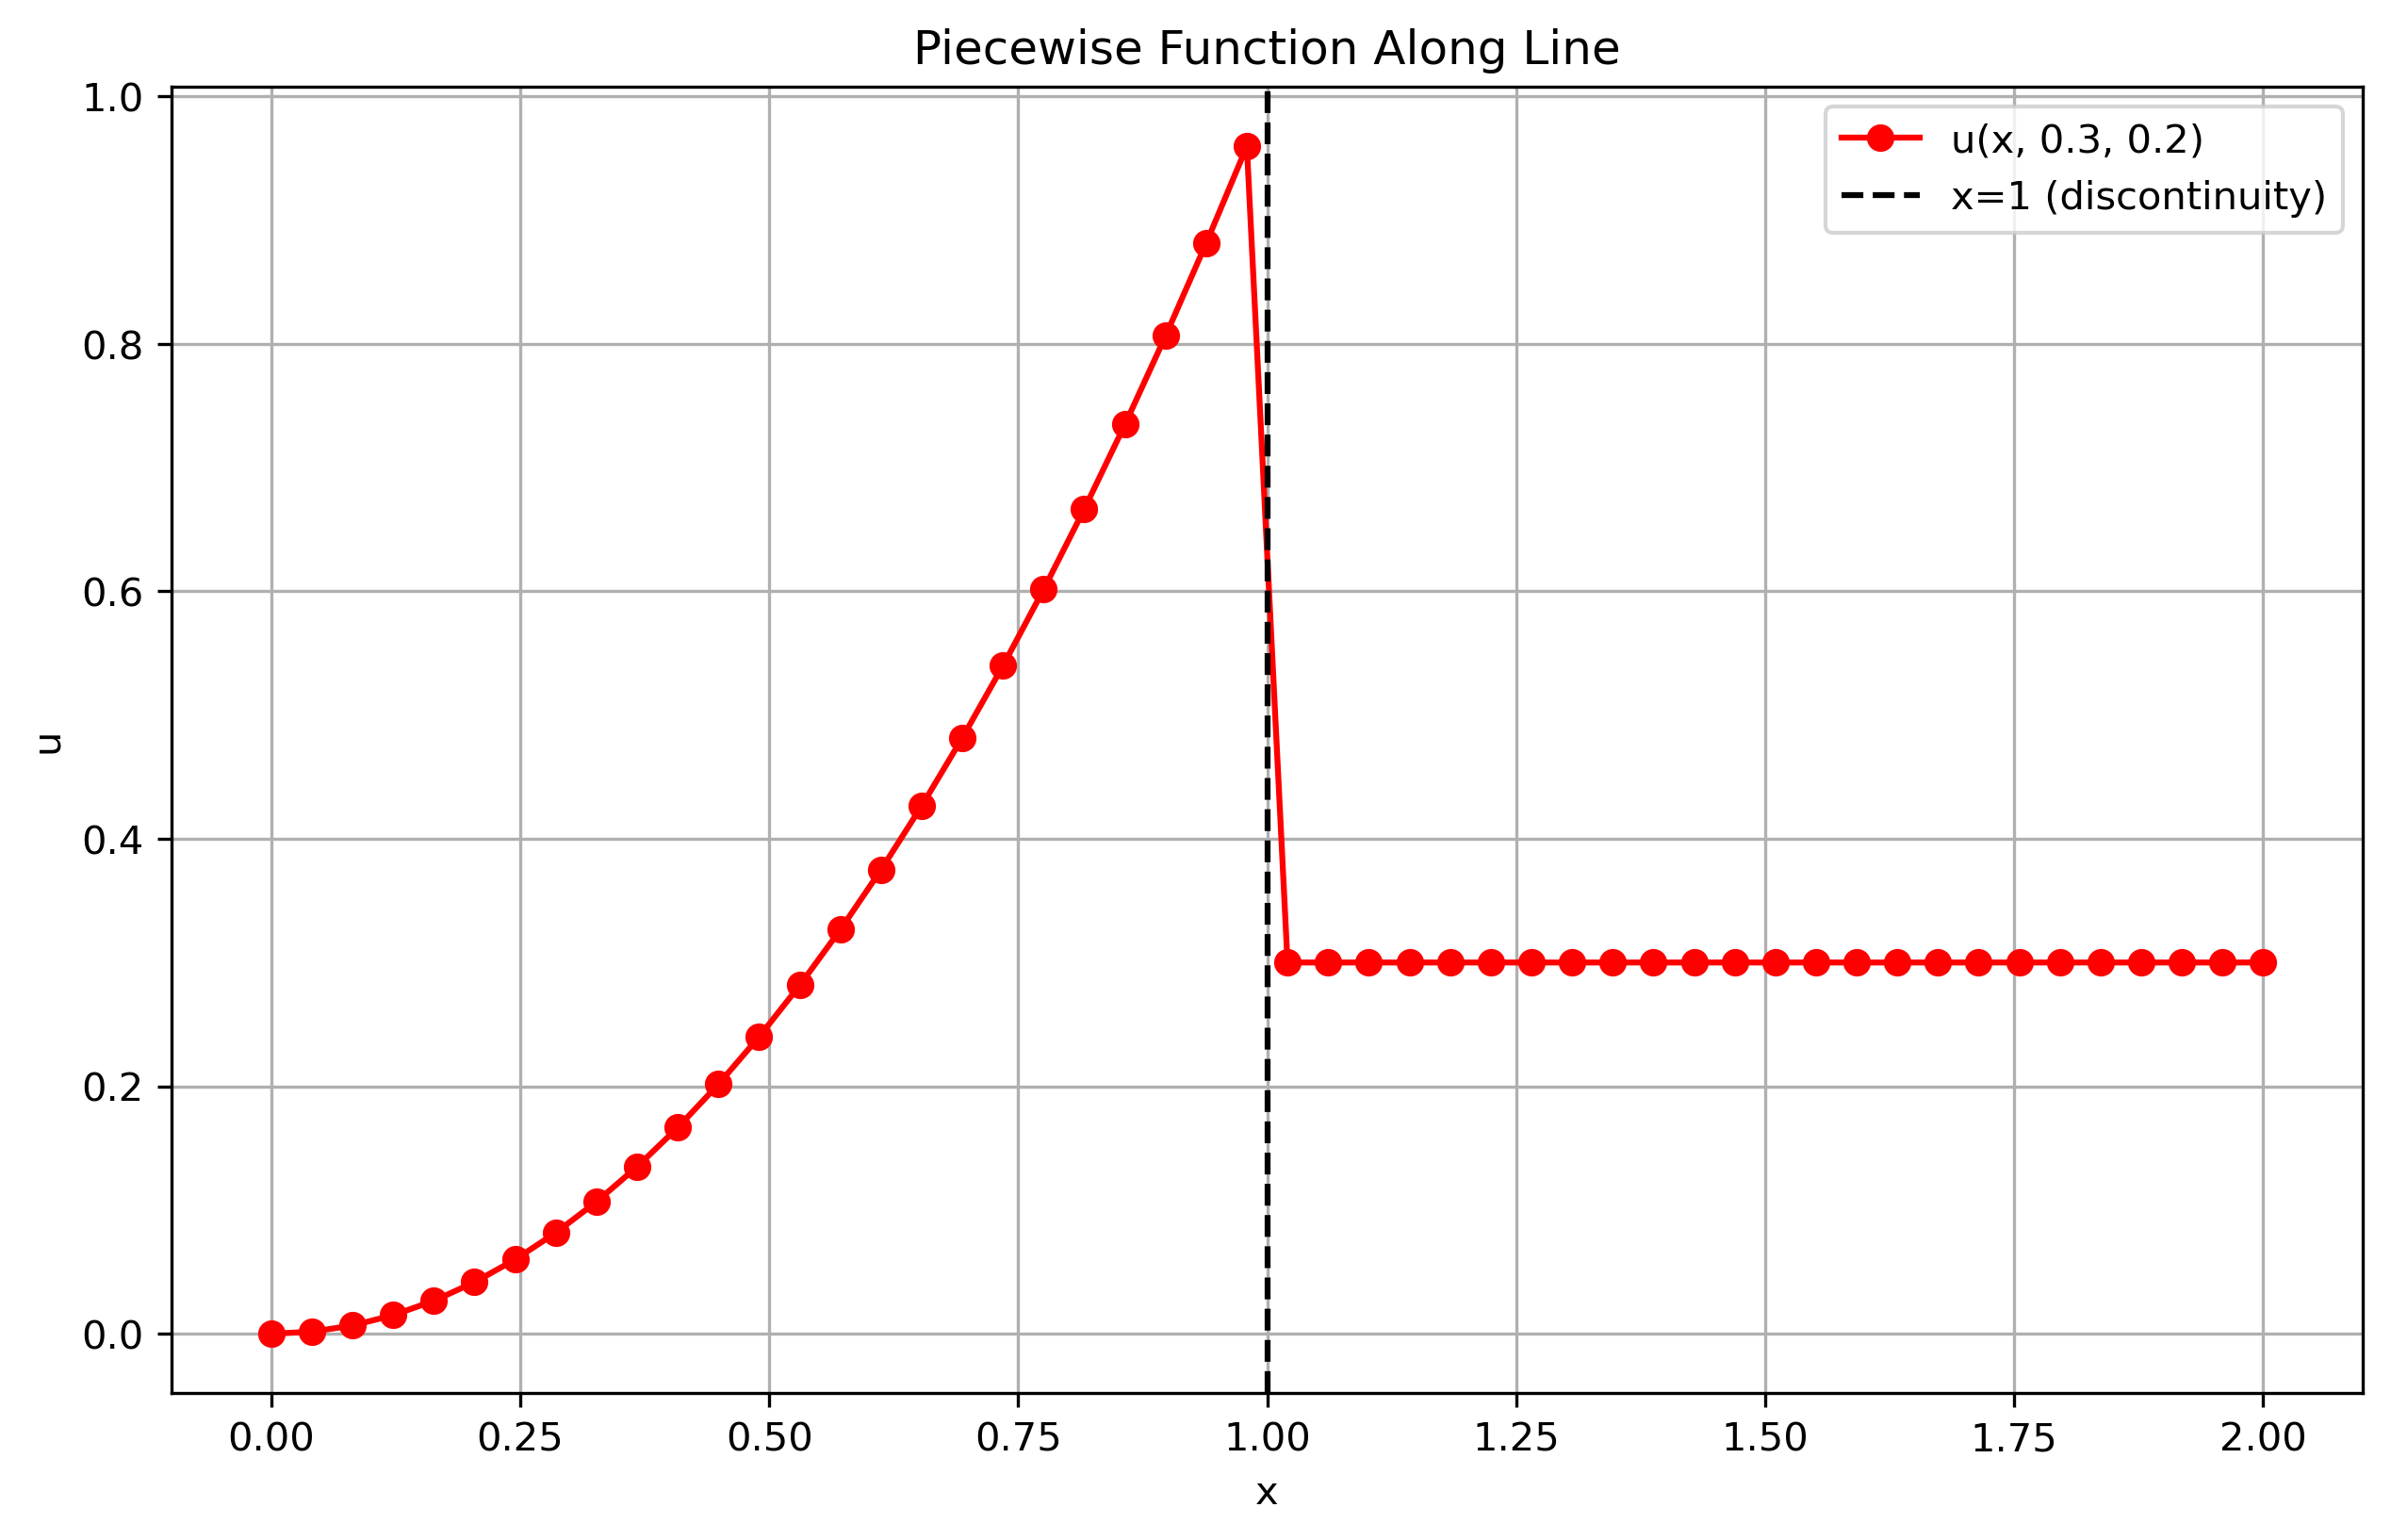

In [3]:
from IPython.display import Image, display, HTML

display(Image("u_along_line.png"))